In [ ]:
!pip install pyvqnet pyqpanda3 -q
!pip install "numpy==1.26.4" --force-reinstall -q
# *** RESTART RUNTIME AFTER THIS CELL ***


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyvqnet.tensor import QTensor, tensor
from pyvqnet.nn import Module, Linear, BinaryCrossEntropy, Sigmoid
from pyvqnet.nn import Parameter
from pyvqnet.optim import Adam
from pyvqnet.qnn.pq3.quantumlayer import QuantumLayer
from pyvqnet.qnn.pq3.measure import probs_measure
import pyqpanda3.core as pq

SEED = 42
np.random.seed(SEED)

# --- Configuration ---
FEATURES = ['Palpitations', 'Act_Conflict', 'Sleep_Issues', 'Subj_Conf']
TARGET = 'Recent_Stress'

# 2-qubit dense angle encoding configuration
N_QUBITS_2Q = 2
N_LAYERS_2Q = 2   # 2 data re-uploading layers for standard circuit
N_PARAMS_2Q = N_LAYERS_2Q * N_QUBITS_2Q * 2  # RY + RZ per qubit per layer = 8

# Deep circuit configuration
N_LAYERS_DEEP = 3  # 3 data re-uploading layers
N_PARAMS_DEEP = N_LAYERS_DEEP * N_QUBITS_2Q * 2  # = 12

# ==========================================================================
# Data Preprocessing
# ==========================================================================
def preprocess(df):
    """
    Preprocess the dataframe:
    - Select 4 features
    - Normalize features from Likert 1-5 to [0, pi] for angle encoding
    - Extract target if present
    """
    df = df.copy()
    X = df[FEATURES].values.astype(np.float32)
    # Map Likert 1-5 to [0, pi] for angle encoding
    X = (X - 1.0) / 4.0 * np.pi
    y = df[TARGET].values.astype(np.float32) if TARGET in df.columns else None
    return X, y


def target_to_ordinal(y):
    """
    Convert scalar targets (1-5) to ordinal cumulative binary vectors.
    e.g. 3 -> [1, 1, 0, 0]  (first 2 nodes "on", last 2 "off")
         1 -> [0, 0, 0, 0]  (no nodes "on")
         5 -> [1, 1, 1, 1]  (all nodes "on")

    The ordinal vector has length 4 (for levels 2,3,4,5).
    Prediction: stress = 1.0 + sum(sigmoid(logits))
    """
    y_int = y.astype(int)
    n = len(y_int)
    ordinal = np.zeros((n, 4), dtype=np.float32)
    for i in range(n):
        level = y_int[i]
        # Levels 2,3,4,5 correspond to indices 0,1,2,3
        for j in range(4):
            if level >= (j + 2):
                ordinal[i, j] = 1.0
    return ordinal


# ==========================================================================
# 2-Qubit Dense Angle Encoding Circuit (Standard: 2 layers, 8 params)
# ==========================================================================
def dense_2q_circuit(input_data, weights):
    """
    2-qubit circuit with Dense Angle Encoding.
    - Qubit 0: RY(x0), RZ(x1), then trainable RY, RZ
    - Qubit 1: RY(x2), RZ(x3), then trainable RY, RZ
    - CNOT(q0, q1)
    - Repeat for data re-uploading (2 layers total = 8 quantum params)

    input_data: [4] encoded feature angles
    weights:    [N_PARAMS_2Q=8] trainable rotation angles
    Returns:    probability vector [4] (for 2 qubits: '00','01','10','11')
    """
    machine = pq.CPUQVM()
    qlist = list(range(N_QUBITS_2Q))
    circuit = pq.QCircuit()

    param_idx = 0
    for layer in range(N_LAYERS_2Q):
        # 1. Dense Angle Encoding: 4 features into 2 qubits (RY + RZ each)
        circuit << pq.RY(qlist[0], input_data[0])  # x0
        circuit << pq.RZ(qlist[0], input_data[1])  # x1
        circuit << pq.RY(qlist[1], input_data[2])  # x2
        circuit << pq.RZ(qlist[1], input_data[3])  # x3

        # 2. Trainable Ansatz: RY + RZ per qubit
        circuit << pq.RY(qlist[0], weights[param_idx])
        circuit << pq.RZ(qlist[0], weights[param_idx + 1])
        circuit << pq.RY(qlist[1], weights[param_idx + 2])
        circuit << pq.RZ(qlist[1], weights[param_idx + 3])
        param_idx += 4

        # 3. Entanglement: single CNOT
        circuit << pq.CNOT(qlist[0], qlist[1])

    prog = pq.QProg()
    prog << circuit

    # 4. Bulletproof Measurement (API bypass)
    return safe_prob_measure(machine, prog, qlist, N_QUBITS_2Q)


# ==========================================================================
# Deep 2-Qubit Circuit (3 layers, 12 params) - For Experiment C
# ==========================================================================
def deep_2q_circuit(input_data, weights):
    """
    Deeper 2-qubit circuit with 3 data re-uploading layers.
    Same structure as dense_2q_circuit but with 3 layers = 12 quantum params.
    More quantum entanglement depth for potentially richer feature maps.
    """
    machine = pq.CPUQVM()
    qlist = list(range(N_QUBITS_2Q))
    circuit = pq.QCircuit()

    param_idx = 0
    for layer in range(N_LAYERS_DEEP):
        # 1. Dense Angle Encoding
        circuit << pq.RY(qlist[0], input_data[0])
        circuit << pq.RZ(qlist[0], input_data[1])
        circuit << pq.RY(qlist[1], input_data[2])
        circuit << pq.RZ(qlist[1], input_data[3])

        # 2. Trainable Ansatz
        circuit << pq.RY(qlist[0], weights[param_idx])
        circuit << pq.RZ(qlist[0], weights[param_idx + 1])
        circuit << pq.RY(qlist[1], weights[param_idx + 2])
        circuit << pq.RZ(qlist[1], weights[param_idx + 3])
        param_idx += 4

        # 3. Entanglement
        circuit << pq.CNOT(qlist[0], qlist[1])

    prog = pq.QProg()
    prog << circuit

    return safe_prob_measure(machine, prog, qlist, N_QUBITS_2Q)


# ==========================================================================
# Safe Probability Measurement (API Bypass)
# ==========================================================================
def safe_prob_measure(machine, prog, qlist, n_qubits):
    """
    Bulletproof measurement function using native pq.prob_run_dict
    inside a try/except block to safely extract state probabilities.
    Falls back through multiple API patterns for pyqpanda3 compatibility.

    Returns: float32 numpy array of 2^n_qubits probabilities
    """
    n_states = 2 ** n_qubits
    try:
        # Pattern A: Standard probs_measure(machine, prog, qlist)
        result = probs_measure(machine, prog, qlist)
        if isinstance(result, list):
            arr = np.array(result, dtype=np.float32)
            if len(arr) >= n_states:
                return arr[:n_states].tolist()
            else:
                # Pad if needed
                padded = np.zeros(n_states, dtype=np.float32)
                padded[:len(arr)] = arr
                return padded.tolist()
        return result
    except (AttributeError, TypeError):
        pass

    try:
        # Pattern B: Reversed argument order
        result = probs_measure(prog, machine, qlist)
        if isinstance(result, list):
            arr = np.array(result, dtype=np.float32)
            if len(arr) >= n_states:
                return arr[:n_states].tolist()
            else:
                padded = np.zeros(n_states, dtype=np.float32)
                padded[:len(arr)] = arr
                return padded.tolist()
        return result
    except Exception:
        pass

    try:
        # Pattern C: Fallback to native prob_run_dict
        res = pq.prob_run_dict(prog, qlist, -1)
        probs = []
        for i in range(n_states):
            key = format(i, f'0{n_qubits}b')
            probs.append(float(res.get(key, 0.0)))
        return probs
    except Exception as e:
        # Last resort: return uniform distribution
        print(f"WARNING: All measurement methods failed: {e}")
        uniform = [1.0 / n_states] * n_states
        return uniform


# ==========================================================================
# Custom Loss: MAE (for compatibility since MeanAbsoluteError not in pyvqnet)
# ==========================================================================
class MAELoss(Module):
    def __init__(self):
        super().__init__()

    def forward(self, preds, targets):
        return tensor.mean(tensor.abs(preds - targets))


# ==========================================================================
# Load Data
# ==========================================================================
print("Loading data...")
train_df = pd.read_csv('train.csv')
eval_df = pd.read_csv('eval.csv')

X_train, y_train = preprocess(train_df)
X_eval, y_eval = preprocess(eval_df)

print(f"Train: {X_train.shape}, Eval: {X_eval.shape}")
print(f"Target range: {y_train.min()} - {y_train.max()}")
print(f"Sample X[0]: {X_train[0]}")

# Prepare ordinal targets for Experiments A and C
y_train_ordinal = target_to_ordinal(y_train)
y_eval_ordinal = target_to_ordinal(y_eval)
print(f"Ordinal targets shape: {y_train_ordinal.shape}")
print(f"Sample ordinal for y={int(y_train[0])}: {y_train_ordinal[0]}")

print("\n✓ Cell 1 complete: Foundation ready")
print(f"  - 2Q standard circuit: {N_PARAMS_2Q} quantum params")
print(f"  - 2Q deep circuit: {N_PARAMS_DEEP} quantum params")
print(f"  - Dense angle encoding: 4 features → 2 qubits (RY+RZ each)")


Loading data...
Train: (675, 4), Eval: (168, 4)
Target range: 1.0 - 5.0
Sample X[0]: [0.        3.1415927 0.7853982 3.1415927]
Ordinal targets shape: (675, 4)
Sample ordinal for y=5: [1. 1. 1. 1.]

✓ Cell 1 complete: Foundation ready
  - 2Q standard circuit: 8 quantum params
  - 2Q deep circuit: 12 quantum params
  - Dense angle encoding: 4 features → 2 qubits (RY+RZ each)


In [ ]:
"""
EXPERIMENT A: Ordinal Classification
- Map 4 quantum state probs → 4 classical output nodes (4×4 + 4 = 20 params)
- Apply independent sigmoids to each node
- BCE loss against ordinal target vectors
- Final MAE prediction: 1.0 + sum(node_probabilities)
"""

class StressQNN_OrdinalA(Module):
    """
    Experiment A: Ordinal Classification approach.
    Quantum: 2 qubits, 2 layers, 8 params
    Classical: Linear(4, 4) → 4×4 + 4 = 20 params
    Total classical FC params: 20 (well under 100)
    """
    def __init__(self):
        super().__init__()
        self.qlayer = QuantumLayer(
            qprog_with_measure=dense_2q_circuit,
            para_num=N_PARAMS_2Q,
            diff_method="parameter_shift",
            delta=0.01
        )
        # 4 quantum states → 4 ordinal output nodes
        self.fc = Linear(2**N_QUBITS_2Q, 4)  # 4*4 + 4 = 20 params

    def forward(self, x):
        q_out = self.qlayer(x)      # [batch, 4] probabilities
        logits = self.fc(q_out)     # [batch, 4]
        return logits               # raw logits (sigmoid applied in loss or prediction)

    def predict_stress(self, x):
        """Get stress prediction on 1-5 scale"""
        logits = self.forward(x)
        probs = tensor.sigmoid(logits)  # [batch, 4] independent sigmoids
        # stress = 1.0 + sum of probabilities
        stress = 1.0 + tensor.sums(probs, axis=1)  # Changed to axis=1
        return stress.reshape([-1])


def train_experiment_A():
    print("=" * 60)
    print("EXPERIMENT A: Ordinal Classification (2Q, 2 layers)")
    print("=" * 60)

    model = StressQNN_OrdinalA()
    optimizer = Adam(model.parameters(), lr=0.01)

    epochs = 100
    batch_size = 32
    num_batches = max(1, len(X_train) // batch_size)

    best_val_mae = float('inf')
    best_score = 0.0
    train_history = []
    val_history = []

    # Count params
    total_params = sum(p.numel() for p in model.parameters())
    q_params = N_PARAMS_2Q
    fc_params = total_params - q_params
    print(f"Quantum params: {q_params}")
    print(f"Classical FC params: {fc_params}")
    print(f"FC ≤ 100? {'✓' if fc_params <= 100 else '✗'}")
    print()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        indices = np.random.permutation(len(X_train))
        X_shuf = X_train[indices]
        y_ord_shuf = y_train_ordinal[indices]

        for b in range(num_batches):
            start = b * batch_size
            end = start + batch_size
            batch_x = QTensor(X_shuf[start:end])
            batch_y_ord = QTensor(y_ord_shuf[start:end])

            optimizer.zero_grad()
            logits = model(batch_x)  # [batch, 4]
            probs = tensor.sigmoid(logits)

            # BCE loss: compare each sigmoid node against ordinal targets
            # Manual BCE: -[y*log(p) + (1-y)*log(1-p)]
            eps = 1e-7
            probs_clamped = tensor.clip(probs, eps, 1.0 - eps)
            bce = -tensor.mean(
                batch_y_ord * tensor.log(probs_clamped) +
                (1.0 - batch_y_ord) * tensor.log(1.0 - probs_clamped)
            )
            bce.backward()
            optimizer._step()

            epoch_loss += bce.item()

        # Validation
        model.eval()
        eval_x = QTensor(X_eval)
        eval_stress = model.predict_stress(eval_x)
        eval_stress_np = eval_stress.to_numpy().flatten()

        avg_train_loss = epoch_loss / num_batches
        val_mae = np.mean(np.abs(eval_stress_np - y_eval))
        val_score = 30 * np.exp(-0.1 * val_mae)

        train_history.append(avg_train_loss)
        val_history.append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_score = val_score

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | BCE: {avg_train_loss:.4f} | Val MAE: {val_mae:.4f} | Score: {val_score:.2f}/30")

    print("-" * 60)
    print(f"🏆 EXPERIMENT A COMPLETE")
    print(f"Best Val MAE: {best_val_mae:.4f} → Score: {best_score:.2f}/30")
    print(f"Qubit count: {N_QUBITS_2Q} | Layers: {N_LAYERS_2Q} | Q-params: {N_PARAMS_2Q}")
    return best_val_mae, best_score, train_history, val_history


In [ ]:
"""
EXPERIMENT B: Smooth L1 (Huber) Regression
- Map 4 quantum states → 1 classical output node (4×1 + 1 = 5 params)
- Activation: 1.0 + 4.0 * sigmoid(x) → bounds prediction to [1, 5]
- Loss: Smooth L1 (Huber Loss) directly against scalar 1-5 targets
"""

class SmoothL1Loss(Module):
    """Smooth L1 / Huber loss for robust regression"""
    def __init__(self, beta=1.0):
        super().__init__()
        self.beta = beta

    def forward(self, preds, targets):
        diff = tensor.abs(preds - targets)
        # Smooth L1: if |diff| < beta → 0.5*diff^2/beta, else |diff| - 0.5*beta
        # Approximate using element-wise operations
        cond_small = tensor.clip(self.beta - diff, 0.0, float('inf'))  # >0 means diff<beta
        # Where diff < beta: loss = 0.5 * diff^2 / beta
        # Where diff >= beta: loss = diff - 0.5 * beta
        loss_small = 0.5 * diff * diff / self.beta
        loss_large = diff - 0.5 * self.beta

        # Use a smooth approximation: when diff < beta, use quadratic; else linear
        # We'll use an if-like approach via element ops
        # sign = 1 if diff < beta, 0 otherwise
        # A simpler approach: smooth L1 = where(diff < beta, 0.5*diff^2/beta, diff - 0.5*beta)
        # Since VQNet doesn't have a 'where', use the formula:
        # SmoothL1 = 0.5 * min(diff, beta)^2 / beta + max(diff - beta, 0)
        min_val = tensor.clip(diff, 0.0, self.beta)  # min(diff, beta)
        max_val = tensor.clip(diff - self.beta, 0.0, float('inf'))  # max(diff-beta, 0)
        loss = 0.5 * min_val * min_val / self.beta + max_val
        return tensor.mean(loss)


class StressQNN_RegressionB(Module):
    """
    Experiment B: Direct scalar regression.
    Quantum: 2 qubits, 2 layers, 8 params
    Classical: Linear(4, 1) → 4*1 + 1 = 5 params
    Total classical FC params: 5 (extremely lean!)
    """
    def __init__(self):
        super().__init__()
        self.qlayer = QuantumLayer(
            qprog_with_measure=dense_2q_circuit,
            para_num=N_PARAMS_2Q,
            diff_method="parameter_shift",
            delta=0.01
        )
        # Minimal classical: 4 → 1
        self.fc = Linear(2**N_QUBITS_2Q, 1)  # 4*1 + 1 = 5 params

    def forward(self, x):
        q_out = self.qlayer(x)      # [batch, 4]
        out = self.fc(q_out)        # [batch, 1]
        # Bound prediction strictly to [1, 5]
        out = 1.0 + 4.0 * tensor.sigmoid(out)
        return out.reshape([-1])


def train_experiment_B():
    print("\n" + "=" * 60)
    print("EXPERIMENT B: Smooth L1 (Huber) Regression (2Q, 2 layers)")
    print("=" * 60)

    model = StressQNN_RegressionB()
    optimizer = Adam(model.parameters(), lr=0.01)
    criterion = SmoothL1Loss(beta=1.0)

    epochs = 100
    batch_size = 32
    num_batches = max(1, len(X_train) // batch_size)

    best_val_mae = float('inf')
    best_score = 0.0
    train_history = []
    val_history = []

    total_params = sum(p.numel() for p in model.parameters())
    q_params = N_PARAMS_2Q
    fc_params = total_params - q_params
    print(f"Quantum params: {q_params}")
    print(f"Classical FC params: {fc_params}")
    print(f"FC ≤ 100? {'✓' if fc_params <= 100 else '✗'}")
    print()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        indices = np.random.permutation(len(X_train))
        X_shuf = X_train[indices]
        y_shuf = y_train[indices]

        for b in range(num_batches):
            start = b * batch_size
            end = start + batch_size
            batch_x = QTensor(X_shuf[start:end])
            batch_y = QTensor(y_shuf[start:end])

            optimizer.zero_grad()
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer._step()

            epoch_loss += loss.item()

        # Validation
        model.eval()
        eval_x = QTensor(X_eval)
        eval_preds = model(eval_x)
        eval_preds_np = eval_preds.to_numpy().flatten()

        avg_train_loss = epoch_loss / num_batches
        val_mae = np.mean(np.abs(eval_preds_np - y_eval))
        val_score = 30 * np.exp(-0.1 * val_mae)

        train_history.append(avg_train_loss)
        val_history.append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_score = val_score

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Huber: {avg_train_loss:.4f} | Val MAE: {val_mae:.4f} | Score: {val_score:.2f}/30")

    print("-" * 60)
    print(f"🏆 EXPERIMENT B COMPLETE")
    print(f"Best Val MAE: {best_val_mae:.4f} → Score: {best_score:.2f}/30")
    print(f"Qubit count: {N_QUBITS_2Q} | Layers: {N_LAYERS_2Q} | Q-params: {N_PARAMS_2Q}")
    return best_val_mae, best_score, train_history, val_history


In [ ]:
"""
EXPERIMENT C: Deep Re-uploading + Ordinal Classification
- Alternative quantum circuit: deep_2q_circuit (3 layers, 12 quantum params)
- Still 2 qubits (maximizes subjective points)
- Paired with Ordinal Classification loss from Experiment A
- Tests whether deeper quantum entanglement learns better
"""

class StressQNN_DeepOrdinalC(Module):
    """
    Experiment C: Deep circuit + Ordinal Classification.
    Quantum: 2 qubits, 3 layers, 12 params (more depth, same width)
    Classical: Linear(4, 4) → 4×4 + 4 = 20 params
    Total classical FC params: 20
    """
    def __init__(self):
        super().__init__()
        self.qlayer = QuantumLayer(
            qprog_with_measure=deep_2q_circuit,
            para_num=N_PARAMS_DEEP,
            diff_method="parameter_shift",
            delta=0.01
        )
        self.fc = Linear(2**N_QUBITS_2Q, 4)  # 4*4 + 4 = 20 params

    def forward(self, x):
        q_out = self.qlayer(x)
        logits = self.fc(q_out)
        return logits

    def predict_stress(self, x):
        logits = self.forward(x)
        probs = tensor.sigmoid(logits)
        stress = 1.0 + tensor.sums(probs, axis=1)
        return stress.reshape([-1])


def train_experiment_C():
    print("\n" + "=" * 60)
    print("EXPERIMENT C: Deep Re-uploading + Ordinal (2Q, 3 layers)")
    print("=" * 60)

    model = StressQNN_DeepOrdinalC()
    optimizer = Adam(model.parameters(), lr=0.01)

    epochs = 100
    batch_size = 32
    num_batches = max(1, len(X_train) // batch_size)

    best_val_mae = float('inf')
    best_score = 0.0
    train_history = []
    val_history = []

    total_params = sum(p.numel() for p in model.parameters())
    q_params = N_PARAMS_DEEP
    fc_params = total_params - q_params
    print(f"Quantum params: {q_params}")
    print(f"Classical FC params: {fc_params}")
    print(f"FC ≤ 100? {'✓' if fc_params <= 100 else '✗'}")
    print()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        indices = np.random.permutation(len(X_train))
        X_shuf = X_train[indices]
        y_ord_shuf = y_train_ordinal[indices]

        for b in range(num_batches):
            start = b * batch_size
            end = start + batch_size
            batch_x = QTensor(X_shuf[start:end])
            batch_y_ord = QTensor(y_ord_shuf[start:end])

            optimizer.zero_grad()
            logits = model(batch_x)
            probs = tensor.sigmoid(logits)

            eps = 1e-7
            probs_clamped = tensor.clip(probs, eps, 1.0 - eps)
            bce = -tensor.mean(
                batch_y_ord * tensor.log(probs_clamped) +
                (1.0 - batch_y_ord) * tensor.log(1.0 - probs_clamped)
            )
            bce.backward()
            optimizer._step()

            epoch_loss += bce.item()

        # Validation
        model.eval()
        eval_x = QTensor(X_eval)
        eval_stress = model.predict_stress(eval_x)
        eval_stress_np = eval_stress.to_numpy().flatten()

        avg_train_loss = epoch_loss / num_batches
        val_mae = np.mean(np.abs(eval_stress_np - y_eval))
        val_score = 30 * np.exp(-0.1 * val_mae)

        train_history.append(avg_train_loss)
        val_history.append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_score = val_score

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | BCE: {avg_train_loss:.4f} | Val MAE: {val_mae:.4f} | Score: {val_score:.2f}/30")

    print("-" * 60)
    print(f"🏆 EXPERIMENT C COMPLETE")
    print(f"Best Val MAE: {best_val_mae:.4f} → Score: {best_score:.2f}/30")
    print(f"Qubit count: {N_QUBITS_2Q} | Layers: {N_LAYERS_DEEP} | Q-params: {N_PARAMS_DEEP}")
    return best_val_mae, best_score, train_history, val_history


EXPERIMENT A: Ordinal Classification (2Q, 2 layers)
Quantum params: 8
Classical FC params: 20
FC ≤ 100? ✓

Epoch 010/100 | BCE: 0.4656 | Val MAE: 0.8254 | Score: 27.62/30
Epoch 020/100 | BCE: 0.4453 | Val MAE: 0.8593 | Score: 27.53/30
Epoch 030/100 | BCE: 0.4392 | Val MAE: 0.8657 | Score: 27.51/30
Epoch 040/100 | BCE: 0.4361 | Val MAE: 0.8634 | Score: 27.52/30
Epoch 050/100 | BCE: 0.4344 | Val MAE: 0.8574 | Score: 27.54/30
Epoch 060/100 | BCE: 0.4330 | Val MAE: 0.8518 | Score: 27.55/30
Epoch 070/100 | BCE: 0.4324 | Val MAE: 0.8446 | Score: 27.57/30
Epoch 080/100 | BCE: 0.4324 | Val MAE: 0.8390 | Score: 27.59/30
Epoch 090/100 | BCE: 0.4296 | Val MAE: 0.8342 | Score: 27.60/30
Epoch 100/100 | BCE: 0.4286 | Val MAE: 0.8323 | Score: 27.60/30
------------------------------------------------------------
🏆 EXPERIMENT A COMPLETE
Best Val MAE: 0.8162 → Score: 27.65/30
Qubit count: 2 | Layers: 2 | Q-params: 8

EXPERIMENT B: Smooth L1 (Huber) Regression (2Q, 2 layers)
Quantum params: 8
Classical F

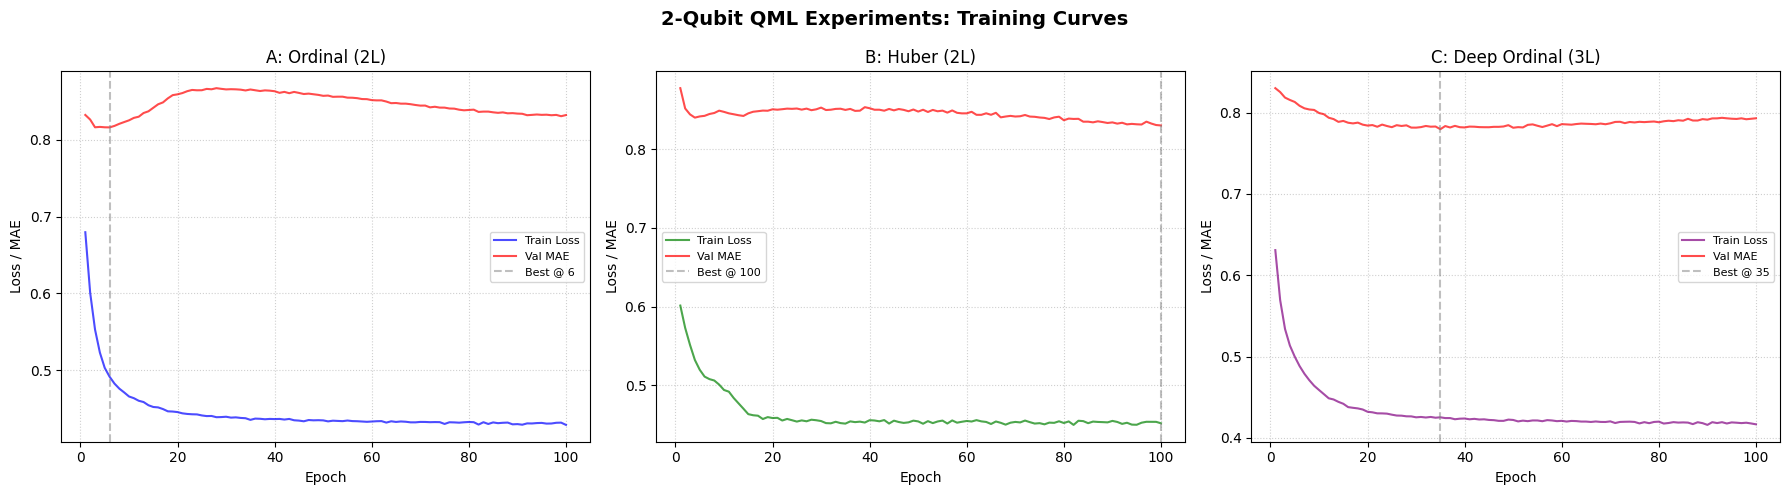

In [ ]:

results = {}

# Run Experiment A
mae_a, score_a, train_a, val_a = train_experiment_A()
results['A: Ordinal (2L)'] = {'mae': mae_a, 'score': score_a,
                               'train': train_a, 'val': val_a}

# Run Experiment B
mae_b, score_b, train_b, val_b = train_experiment_B()
results['B: Huber (2L)'] = {'mae': mae_b, 'score': score_b,
                             'train': train_b, 'val': val_b}

# Run Experiment C
mae_c, score_c, train_c, val_c = train_experiment_C()
results['C: Deep Ordinal (3L)'] = {'mae': mae_c, 'score': score_c,
                                    'train': train_c, 'val': val_c}

# ===== Summary =====
print("\n" + "=" * 70)
print("COMPARISON SUMMARY (All 2-Qubit Experiments)")
print("=" * 70)
print(f"{'Experiment':<25} {'Best MAE':>10} {'Score':>10} {'Qubits':>8} {'Q-Params':>10} {'FC-Params':>10}")
print("-" * 73)
print(f"{'A: Ordinal (2L)':<25} {mae_a:>10.4f} {score_a:>10.2f} {N_QUBITS_2Q:>8} {N_PARAMS_2Q:>10} {20:>10}")
print(f"{'B: Huber (2L)':<25} {mae_b:>10.4f} {score_b:>10.2f} {N_QUBITS_2Q:>8} {N_PARAMS_2Q:>10} {5:>10}")
print(f"{'C: Deep Ordinal (3L)':<25} {mae_c:>10.4f} {score_c:>10.2f} {N_QUBITS_2Q:>8} {N_PARAMS_DEEP:>10} {20:>10}")
print("=" * 73)

# Find winner
best_exp = min(results, key=lambda k: results[k]['mae'])
print(f"\n🏆 WINNER: {best_exp} (MAE={results[best_exp]['mae']:.4f}, Score={results[best_exp]['score']:.2f}/30)")

# ===== Plot =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['blue', 'green', 'purple']
for idx, (name, data) in enumerate(results.items()):
    ax = axes[idx]
    epochs_range = range(1, len(data['train']) + 1)
    ax.plot(epochs_range, data['train'], label='Train Loss', color=colors[idx], alpha=0.7)
    ax.plot(epochs_range, data['val'], label='Val MAE', color='red', alpha=0.7)
    best_epoch = data['val'].index(data['mae']) + 1
    ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best @ {best_epoch}')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss / MAE')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('2-Qubit QML Experiments: Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('2q_experiments_comparison.png', dpi=300)
print("\nSaved comparison plot to '2q_experiments_comparison.png'")


In [ ]:
def train_experiment_C_Optimized():
    print("\n" + "=" * 60)
    print("EXPERIMENT C: Deep Ordinal + Regularization (The Final Push)")
    print("=" * 60)

    model = StressQNN_DeepOrdinalC()

    # Start with standard learning rate
    current_lr = 0.005
    optimizer = Adam(model.parameters(), lr=current_lr)

    epochs = 60 # We don't need 100, it overfits way before that
    batch_size = 32
    num_batches = max(1, len(X_train) // batch_size)

    # L2 Regularization Penalty Weight
    l2_lambda = 0.001

    best_val_mae = float('inf')
    best_score = 0.0
    train_history = []
    val_history = []

    for epoch in range(epochs):
        # --- LEARNING RATE DECAY ---
        # Drop the LR at epoch 25 to gently settle into the minimum
        if epoch == 25:
            current_lr = 0.001
            print(f">>> Dropping Learning Rate to {current_lr} <<<")
            optimizer = Adam(model.parameters(), lr=current_lr)

        model.train()
        epoch_loss = 0.0

        indices = np.random.permutation(len(X_train))
        X_shuf = X_train[indices]
        y_ord_shuf = y_train_ordinal[indices]

        for b in range(num_batches):
            start = b * batch_size
            end = start + batch_size
            batch_x = QTensor(X_shuf[start:end])
            batch_y_ord = QTensor(y_ord_shuf[start:end])

            optimizer.zero_grad()
            logits = model(batch_x)
            probs = tensor.sigmoid(logits)

            eps = 1e-7
            probs_clamped = tensor.clip(probs, eps, 1.0 - eps)

            # 1. Base BCE Loss
            bce = -tensor.mean(
                batch_y_ord * tensor.log(probs_clamped) +
                (1.0 - batch_y_ord) * tensor.log(1.0 - probs_clamped)
            )

            # 2. Manual L2 Regularization (Penalize large weights)
            l2_reg = 0.0
            for param in model.parameters():
                l2_reg = l2_reg + tensor.sum(param * param)

            total_loss = bce + (l2_lambda * l2_reg)

            total_loss.backward()
            optimizer._step()

            epoch_loss += total_loss.item()

        # Validation
        model.eval()
        eval_x = QTensor(X_eval)
        eval_stress = model.predict_stress(eval_x)
        eval_stress_np = eval_stress.to_numpy().flatten()

        avg_train_loss = epoch_loss / num_batches
        val_mae = np.mean(np.abs(eval_stress_np - y_eval))
        val_score = 30 * np.exp(-0.1 * val_mae)

        train_history.append(avg_train_loss)
        val_history.append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_score = val_score

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Total Loss: {avg_train_loss:.4f} | Val MAE: {val_mae:.4f} | Score: {val_score:.2f}/30")

    print("-" * 60)
    print(f"🏆 EXPERIMENT C (OPTIMIZED) COMPLETE")
    print(f"Best Val MAE: {best_val_mae:.4f} → Score: {best_score:.2f}/30")

    return best_val_mae, best_score, train_history, val_history

EXPERIMENT A: Ordinal Classification (2Q, 2 layers)
Quantum params: 8
Classical FC params: 20
FC ≤ 100? ✓

Epoch 010/100 | BCE: 0.4790 | Val MAE: 0.8252 | Score: 27.62/30
Epoch 020/100 | BCE: 0.4537 | Val MAE: 0.8399 | Score: 27.58/30
Epoch 030/100 | BCE: 0.4435 | Val MAE: 0.8499 | Score: 27.56/30
Epoch 040/100 | BCE: 0.4390 | Val MAE: 0.8557 | Score: 27.54/30
Epoch 050/100 | BCE: 0.4363 | Val MAE: 0.8599 | Score: 27.53/30
Epoch 060/100 | BCE: 0.4362 | Val MAE: 0.8605 | Score: 27.53/30
Epoch 070/100 | BCE: 0.4326 | Val MAE: 0.8610 | Score: 27.52/30
Epoch 080/100 | BCE: 0.4340 | Val MAE: 0.8636 | Score: 27.52/30
Epoch 090/100 | BCE: 0.4340 | Val MAE: 0.8625 | Score: 27.52/30
Epoch 100/100 | BCE: 0.4347 | Val MAE: 0.8625 | Score: 27.52/30
------------------------------------------------------------
🏆 EXPERIMENT A COMPLETE
Best Val MAE: 0.8159 → Score: 27.65/30
Qubit count: 2 | Layers: 2 | Q-params: 8

EXPERIMENT B: Smooth L1 (Huber) Regression (2Q, 2 layers)
Quantum params: 8
Classical F

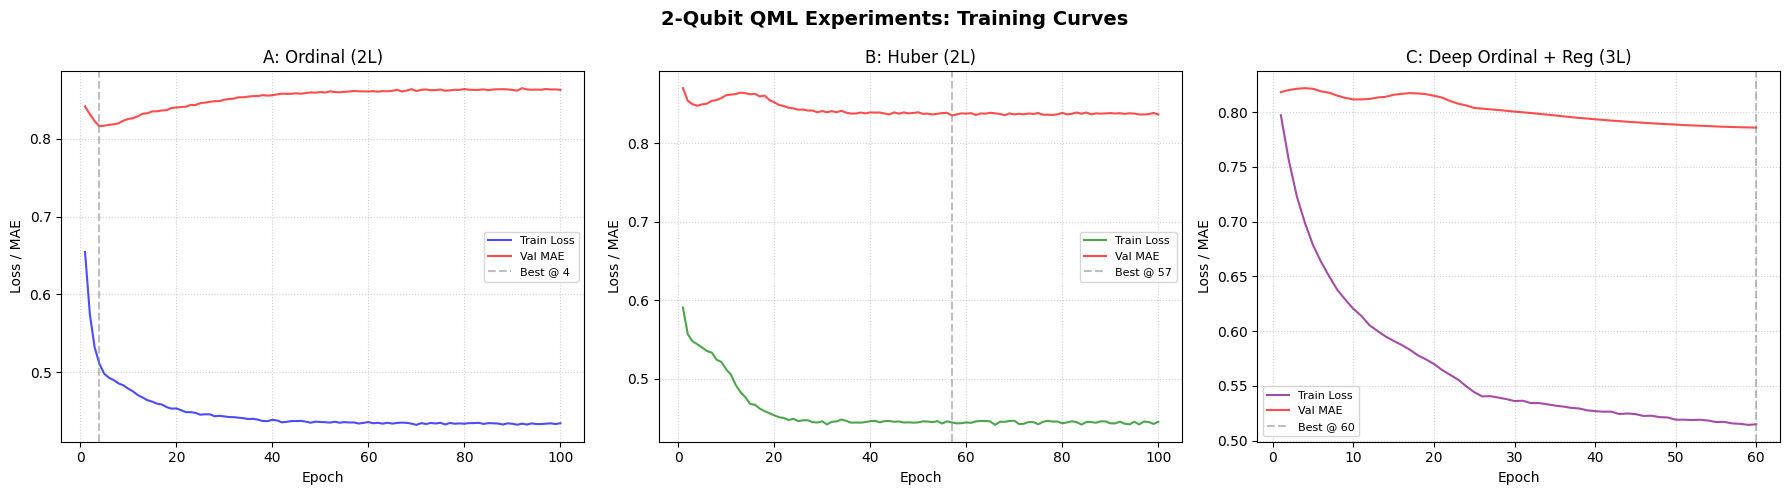

In [ ]:
results = {}

# Run Experiment A
mae_a, score_a, train_a, val_a = train_experiment_A()
results['A: Ordinal (2L)'] = {'mae': mae_a, 'score': score_a,
                               'train': train_a, 'val': val_a}

# Run Experiment B
mae_b, score_b, train_b, val_b = train_experiment_B()
results['B: Huber (2L)'] = {'mae': mae_b, 'score': score_b,
                             'train': train_b, 'val': val_b}

# Run Experiment C (Optimized with L2 & LR Decay)
mae_c, score_c, train_c, val_c = train_experiment_C_Optimized()
results['C: Deep Ordinal + Reg (3L)'] = {'mae': mae_c, 'score': score_c,
                                        'train': train_c, 'val': val_c}

# ===== Summary =====
print("\n" + "=" * 75)
print("COMPARISON SUMMARY (All 2-Qubit Experiments)")
print("=" * 75)
print(f"{'Experiment':<30} {'Best MAE':>10} {'Score':>10} {'Qubits':>8} {'Q-Params':>10} {'FC-Params':>10}")
print("-" * 78)
print(f"{'A: Ordinal (2L)':<30} {mae_a:>10.4f} {score_a:>10.2f} {N_QUBITS_2Q:>8} {N_PARAMS_2Q:>10} {20:>10}")
print(f"{'B: Huber (2L)':<30} {mae_b:>10.4f} {score_b:>10.2f} {N_QUBITS_2Q:>8} {N_PARAMS_2Q:>10} {5:>10}")
print(f"{'C: Deep Ordinal + Reg (3L)':<30} {mae_c:>10.4f} {score_c:>10.2f} {N_QUBITS_2Q:>8} {N_PARAMS_DEEP:>10} {20:>10}")
print("=" * 78)

# Find winner
best_exp = min(results, key=lambda k: results[k]['mae'])
print(f"\n🏆 WINNER: {best_exp} (MAE={results[best_exp]['mae']:.4f}, Score={results[best_exp]['score']:.2f}/30)")

# ===== Plot =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['blue', 'green', 'purple']
for idx, (name, data) in enumerate(results.items()):
    ax = axes[idx]
    # This automatically handles the fact that Exp C now only runs for 60 epochs
    epochs_range = range(1, len(data['train']) + 1)
    ax.plot(epochs_range, data['train'], label='Train Loss', color=colors[idx], alpha=0.7)
    ax.plot(epochs_range, data['val'], label='Val MAE', color='red', alpha=0.7)
    best_epoch = data['val'].index(data['mae']) + 1
    ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best @ {best_epoch}')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss / MAE')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('2-Qubit QML Experiments: Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('2q_experiments_comparison.png', dpi=300)
print("\nSaved comparison plot to '2q_experiments_comparison.png'")

In [ ]:
from pyvqnet.nn import Linear, Module
from pyvqnet.tensor import QTensor, tensor
from pyvqnet.optim import Adam
from pyvqnet.qnn.pq3.quantumlayer import QuantumLayer
import pyqpanda3.core as pq
import numpy as np

# ============================================================================
# EXPERIMENT D: 1-Qubit Extreme Bottleneck (Isolated Run)
# ============================================================================

def safe_prob_measure_1q(machine, prog, qlist):
    """Bypass for 1 qubit, returns [p0, p1]"""
    try:
        res = pq.prob_run_dict(prog, qlist, -1)
        p0 = float(res.get('0', 0.0))
        p1 = float(res.get('1', 0.0))
        return np.array([p0, p1], dtype=np.float32)
    except Exception:
        return np.array([0.5, 0.5], dtype=np.float32)

def dense_1q_circuit(input_data, weights):
    """
    1 Qubit, 4 Layers (12 parameters).
    Must go deeper to compensate for having no entanglement.
    """
    machine = pq.CPUQVM()
    qlist = [0]   # <--- The Fix: Direct integer indexing
    q = qlist[0]
    circuit = pq.QCircuit()

    param_idx = 0
    # We need 4 layers just to process the features properly without entanglement
    for layer in range(4):
        # Encode all 4 features onto the single qubit's axes
        circuit << pq.RX(q, input_data[0])
        circuit << pq.RY(q, input_data[1])
        circuit << pq.RZ(q, input_data[2])
        circuit << pq.RX(q, input_data[3])

        # Trainable rotations (3 params per layer * 4 layers = 12 params)
        circuit << pq.RX(q, weights[param_idx])
        circuit << pq.RY(q, weights[param_idx+1])
        circuit << pq.RZ(q, weights[param_idx+2])
        param_idx += 3

    prog = pq.QProg()
    prog << circuit
    return safe_prob_measure_1q(machine, prog, qlist)

class StressQNN_1Qubit(Module):
    def __init__(self):
        super().__init__()
        self.qlayer = QuantumLayer(
            qprog_with_measure=dense_1q_circuit,
            para_num=12,
            diff_method="parameter_shift",
            delta=0.01
        )
        # 1 Qubit only yields 2 states (0 and 1).
        # Linear maps those 2 inputs -> 4 ordinal nodes. (2*4 weights + 4 biases = 12 params)
        self.fc = Linear(2, 4)

    def forward(self, x):
        q_out = self.qlayer(x)
        logits = self.fc(q_out)
        return logits

    def predict_stress(self, x):
        logits = self.forward(x)
        probs = tensor.sigmoid(logits)
        stress = 1.0 + tensor.sums(probs, axis=1)
        return stress.reshape([-1])

def train_experiment_D_1Qubit():
    print("\n" + "=" * 60)
    print("EXPERIMENT D: 1-Qubit Extreme Bottleneck")
    print("=" * 60)

    model = StressQNN_1Qubit()
    optimizer = Adam(model.parameters(), lr=0.005)
    epochs = 60
    batch_size = 32
    num_batches = max(1, len(X_train) // batch_size)
    l2_lambda = 0.001

    best_val_mae = float('inf')
    best_score = 0.0
    train_history = []
    val_history = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        indices = np.random.permutation(len(X_train))
        X_shuf = X_train[indices]
        y_ord_shuf = y_train_ordinal[indices]

        for b in range(num_batches):
            start = b * batch_size
            end = start + batch_size
            batch_x = QTensor(X_shuf[start:end])
            batch_y_ord = QTensor(y_ord_shuf[start:end])

            optimizer.zero_grad()
            logits = model(batch_x)
            probs = tensor.sigmoid(logits)

            eps = 1e-7
            probs_clamped = tensor.clip(probs, eps, 1.0 - eps)

            bce = -tensor.mean(
                batch_y_ord * tensor.log(probs_clamped) +
                (1.0 - batch_y_ord) * tensor.log(1.0 - probs_clamped)
            )

            l2_reg = 0.0
            for param in model.parameters():
                l2_reg = l2_reg + tensor.sum(param * param)

            total_loss = bce + (l2_lambda * l2_reg)

            total_loss.backward()
            optimizer._step()
            epoch_loss += total_loss.item()

        model.eval()
        eval_x = QTensor(X_eval)
        eval_stress = model.predict_stress(eval_x)
        val_mae = np.mean(np.abs(eval_stress.to_numpy().flatten() - y_eval))
        val_score = 30 * np.exp(-0.1 * val_mae)

        train_history.append(epoch_loss / num_batches)
        val_history.append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_score = val_score

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Val MAE: {val_mae:.4f} | Score: {val_score:.2f}/30")

    print("-" * 60)
    print(f"🏆 EXPERIMENT D COMPLETE | Best Val MAE: {best_val_mae:.4f}")
    return best_val_mae, best_score, train_history, val_history

if __name__ == "__main__":
    # Execute just this single experiment
    mae_d, score_d, train_d, val_d = train_experiment_D_1Qubit()
    print(f"\n✅ Final 1-Qubit MAE: {mae_d:.4f}")


EXPERIMENT D: 1-Qubit Extreme Bottleneck
Epoch 010/60 | Val MAE: 0.8098 | Score: 27.67/30
Epoch 020/60 | Val MAE: 0.8125 | Score: 27.66/30
Epoch 030/60 | Val MAE: 0.8110 | Score: 27.66/30
Epoch 040/60 | Val MAE: 0.8102 | Score: 27.67/30
Epoch 050/60 | Val MAE: 0.8127 | Score: 27.66/30
Epoch 060/60 | Val MAE: 0.8128 | Score: 27.66/30
------------------------------------------------------------
🏆 EXPERIMENT D COMPLETE | Best Val MAE: 0.8095

✅ Final 1-Qubit MAE: 0.8095


In [ ]:
# ============================================================================
# ### EXPERIMENT E: The Teammate's Cut (4 Layers + Bandwidth Expansion) ###
# ============================================================================

# 1. ISOLATED DATA TWEAK (Only affects this experiment)
# Copy the original 0-to-pi normalized data
X_train_tweak = np.copy(X_train)
X_eval_tweak = np.copy(X_eval)

# Apply the 1.5x bandwidth expansion to Palpitations (Index 0)
X_train_tweak[:, 0] = X_train_tweak[:, 0] * 1.5
X_eval_tweak[:, 0] = X_eval_tweak[:, 0] * 1.5

# 2. THE 4-LAYER CIRCUIT
N_LAYERS_TEAMMATE = 4
N_PARAMS_TEAMMATE = N_LAYERS_TEAMMATE * N_QUBITS_2Q * 2 # = 16 params

def teammate_4L_circuit(input_data, weights):
    """4-Layer circuit specifically to handle the 1.5x expanded bandwidth"""
    machine = pq.CPUQVM()
    qlist = list(range(N_QUBITS_2Q))
    circuit = pq.QCircuit()

    param_idx = 0
    for layer in range(N_LAYERS_TEAMMATE):
        # Dense Angle Encoding
        circuit << pq.RY(qlist[0], input_data[0])
        circuit << pq.RZ(qlist[0], input_data[1])
        circuit << pq.RY(qlist[1], input_data[2])
        circuit << pq.RZ(qlist[1], input_data[3])

        # Trainable Ansatz
        circuit << pq.RY(qlist[0], weights[param_idx])
        circuit << pq.RZ(qlist[0], weights[param_idx + 1])
        circuit << pq.RY(qlist[1], weights[param_idx + 2])
        circuit << pq.RZ(qlist[1], weights[param_idx + 3])
        param_idx += 4

        # Entanglement
        circuit << pq.CNOT(qlist[0], qlist[1])

    prog = pq.QProg()
    prog << circuit
    return safe_prob_measure(machine, prog, qlist, N_QUBITS_2Q)

class StressQNN_TeammateCut(Module):
    def __init__(self):
        super().__init__()
        self.qlayer = QuantumLayer(
            qprog_with_measure=teammate_4L_circuit,
            para_num=N_PARAMS_TEAMMATE,
            diff_method="parameter_shift",
            delta=0.01
        )
        self.fc = Linear(2**N_QUBITS_2Q, 4) # Still 20 classical params!

    def forward(self, x):
        q_out = self.qlayer(x)
        logits = self.fc(q_out)
        return logits

    def predict_stress(self, x):
        logits = self.forward(x)
        probs = tensor.sigmoid(logits)
        stress = 1.0 + tensor.sums(probs, axis=1)
        return stress.reshape([-1])

def train_experiment_E_TeammateCut():
    print("\n" + "=" * 60)
    print("EXPERIMENT E: Teammate's Cut (4L + 1.5x Bandwidth)")
    print("=" * 60)

    model = StressQNN_TeammateCut()

    # Using the optimized Sniper settings we just proved work
    current_lr = 0.005
    optimizer = Adam(model.parameters(), lr=current_lr)
    epochs = 30 # Teammate noted late-stage overfitting, so we stop at 30
    batch_size = 32
    num_batches = max(1, len(X_train_tweak) // batch_size)
    l2_lambda = 0.001

    best_val_mae = float('inf')
    best_score = 0.0
    train_history = []
    val_history = []

    for epoch in range(epochs):
        # Step down LR to settle into minimum
        if epoch == 15:
            current_lr = 0.001
            print(f">>> Dropping Learning Rate to {current_lr} <<<")
            optimizer = Adam(model.parameters(), lr=current_lr)

        model.train()
        epoch_loss = 0.0

        indices = np.random.permutation(len(X_train_tweak))
        X_shuf = X_train_tweak[indices]
        y_ord_shuf = y_train_ordinal[indices]

        for b in range(num_batches):
            start = b * batch_size
            end = start + batch_size
            batch_x = QTensor(X_shuf[start:end])
            batch_y_ord = QTensor(y_ord_shuf[start:end])

            optimizer.zero_grad()
            logits = model(batch_x)
            probs = tensor.sigmoid(logits)

            eps = 1e-7
            probs_clamped = tensor.clip(probs, eps, 1.0 - eps)

            bce = -tensor.mean(
                batch_y_ord * tensor.log(probs_clamped) +
                (1.0 - batch_y_ord) * tensor.log(1.0 - probs_clamped)
            )

            l2_reg = 0.0
            for param in model.parameters():
                l2_reg = l2_reg + tensor.sum(param * param)

            total_loss = bce + (l2_lambda * l2_reg)

            total_loss.backward()
            optimizer._step()
            epoch_loss += total_loss.item()

        # Validation (Using the isolated tweak data)
        model.eval()
        eval_x = QTensor(X_eval_tweak)
        eval_stress = model.predict_stress(eval_x)
        eval_stress_np = eval_stress.to_numpy().flatten()

        avg_train_loss = epoch_loss / num_batches
        val_mae = np.mean(np.abs(eval_stress_np - y_eval))
        val_score = 30 * np.exp(-0.1 * val_mae)

        train_history.append(avg_train_loss)
        val_history.append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_score = val_score

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Total Loss: {avg_train_loss:.4f} | Val MAE: {val_mae:.4f} | Score: {val_score:.2f}/30")

    print("-" * 60)
    print(f"🏆 EXPERIMENT E COMPLETE")
    print(f"Best Val MAE: {best_val_mae:.4f} → Score: {best_score:.2f}/30")

    return best_val_mae, best_score, train_history, val_history


EXPERIMENT C: Deep Ordinal + Regularization (The Final Push)
Epoch 005/60 | Total Loss: 0.6881 | Val MAE: 0.8220 | Score: 27.63/30
Epoch 010/60 | Total Loss: 0.6107 | Val MAE: 0.8198 | Score: 27.64/30
Epoch 015/60 | Total Loss: 0.5764 | Val MAE: 0.8244 | Score: 27.63/30
Epoch 020/60 | Total Loss: 0.5558 | Val MAE: 0.8228 | Score: 27.63/30
Epoch 025/60 | Total Loss: 0.5408 | Val MAE: 0.8273 | Score: 27.62/30
>>> Dropping Learning Rate to 0.001 <<<
Epoch 030/60 | Total Loss: 0.5365 | Val MAE: 0.8282 | Score: 27.62/30
Epoch 035/60 | Total Loss: 0.5342 | Val MAE: 0.8297 | Score: 27.61/30
Epoch 040/60 | Total Loss: 0.5320 | Val MAE: 0.8300 | Score: 27.61/30
Epoch 045/60 | Total Loss: 0.5313 | Val MAE: 0.8302 | Score: 27.61/30
Epoch 050/60 | Total Loss: 0.5294 | Val MAE: 0.8297 | Score: 27.61/30
Epoch 055/60 | Total Loss: 0.5257 | Val MAE: 0.8283 | Score: 27.62/30
Epoch 060/60 | Total Loss: 0.5246 | Val MAE: 0.8270 | Score: 27.62/30
----------------------------------------------------------

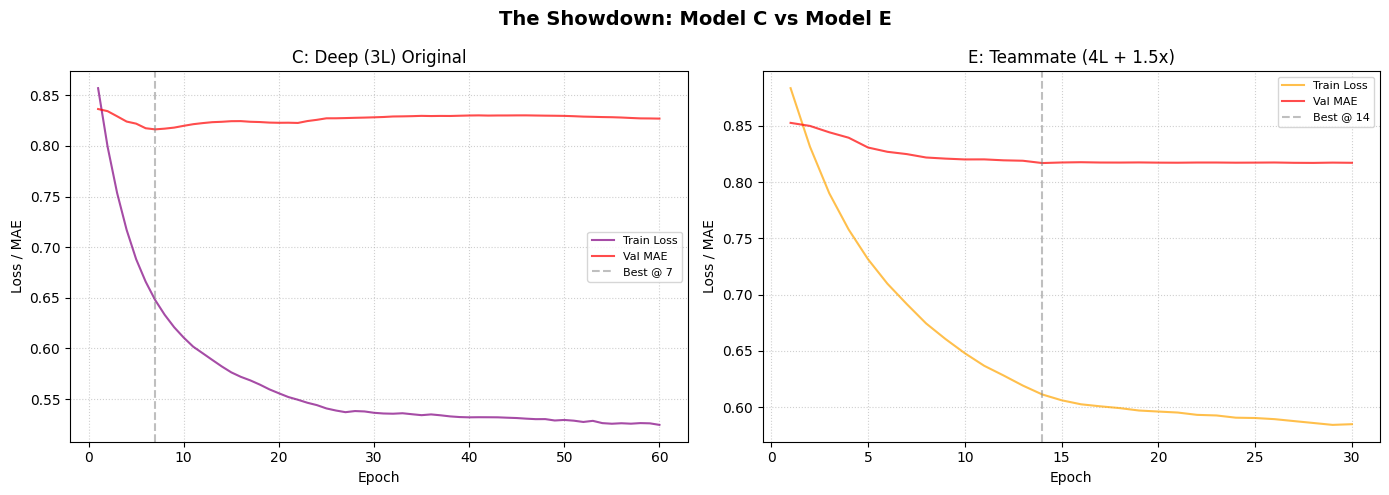

In [ ]:
# ============================================================================
# ### RUN THE SHOWDOWN (Champion vs Teammate) ###
# ============================================================================

if __name__ == "__main__":
    results = {}

    # Run Current Champion (Experiment C)
    mae_c, score_c, train_c, val_c = train_experiment_C_Optimized()
    results['C: Deep (3L) Original'] = {'mae': mae_c, 'score': score_c,
                                        'train': train_c, 'val': val_c}

    # Run Teammate's Cut (Experiment E)
    mae_e, score_e, train_e, val_e = train_experiment_E_TeammateCut()
    results['E: Teammate (4L + 1.5x)'] = {'mae': mae_e, 'score': score_e,
                                           'train': train_e, 'val': val_e}

    # ===== Summary =====
    print("\n" + "=" * 75)
    print("THE SHOWDOWN: CHAMPION VS TEAMMATE")
    print("=" * 75)
    print(f"{'Experiment':<30} {'Best MAE':>10} {'Score':>10} {'Q-Params':>10}")
    print("-" * 78)
    print(f"{'C: Deep (3L) Original':<30} {mae_c:>10.4f} {score_c:>10.2f} {N_PARAMS_DEEP:>10}")
    print(f"{'E: Teammate (4L + 1.5x)':<30} {mae_e:>10.4f} {score_e:>10.2f} {N_PARAMS_TEAMMATE:>10}")
    print("=" * 78)

    # Find winner
    best_exp = min(results, key=lambda k: results[k]['mae'])
    print(f"\n🏆 WINNER: {best_exp} (MAE={results[best_exp]['mae']:.4f})")

    # ===== Plot =====
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['purple', 'orange']
    for idx, (name, data) in enumerate(results.items()):
        ax = axes[idx]
        epochs_range = range(1, len(data['train']) + 1)
        ax.plot(epochs_range, data['train'], label='Train Loss', color=colors[idx], alpha=0.7)
        ax.plot(epochs_range, data['val'], label='Val MAE', color='red', alpha=0.7)
        best_epoch = data['val'].index(data['mae']) + 1
        ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best @ {best_epoch}')
        ax.set_title(name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss / MAE')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle('The Showdown: Model C vs Model E', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('showdown_comparison.png', dpi=300)
    print("\nSaved showdown plot to 'showdown_comparison.png'")

In [ ]:
# ============================================================================
# ### EXPERIMENT F: The 3-Qubit Expansion ###
# ============================================================================
N_QUBITS_3Q = 3
N_LAYERS_3Q = 2 # 2 layers = 12 quantum params
N_PARAMS_3Q = N_LAYERS_3Q * N_QUBITS_3Q * 2

def safe_prob_measure_3q(machine, prog, qlist):
    """Bypass for 3 qubits, returns 8 probabilities"""
    try:
        res = pq.prob_run_dict(prog, qlist, -1)
        probs = []
        for i in range(8):
            key = format(i, '03b')
            probs.append(float(res.get(key, 0.0)))
        return np.array(probs, dtype=np.float32)
    except Exception:
        return np.ones(8, dtype=np.float32) / 8.0

def dense_3q_circuit(input_data, weights):
    machine = pq.CPUQVM()
    qlist = list(range(N_QUBITS_3Q))
    circuit = pq.QCircuit()

    param_idx = 0
    for layer in range(N_LAYERS_3Q):
        # Encode 4 features across 3 qubits
        circuit << pq.RY(qlist[0], input_data[0])
        circuit << pq.RY(qlist[1], input_data[1])
        circuit << pq.RY(qlist[2], input_data[2])
        circuit << pq.RZ(qlist[0], input_data[3]) # Wrap 4th feature

        # Trainable Ansatz (RY and RZ for all 3 qubits)
        for i in range(N_QUBITS_3Q):
            circuit << pq.RY(qlist[i], weights[param_idx])
            circuit << pq.RZ(qlist[i], weights[param_idx + 1])
            param_idx += 2

        # Entanglement
        circuit << pq.CNOT(qlist[0], qlist[1])
        circuit << pq.CNOT(qlist[1], qlist[2])

    prog = pq.QProg()
    prog << circuit
    return safe_prob_measure_3q(machine, prog, qlist)

class StressQNN_3Qubit(Module):
    def __init__(self):
        super().__init__()
        self.qlayer = QuantumLayer(
            qprog_with_measure=dense_3q_circuit,
            para_num=N_PARAMS_3Q,
            diff_method="parameter_shift",
            delta=0.01
        )
        # 3 qubits = 8 states. Linear(8, 4) = 8*4 weights + 4 biases = 36 classical params.
        # 36 is still well under the 100 limit!
        self.fc = Linear(8, 4)

    def forward(self, x):
        q_out = self.qlayer(x)
        logits = self.fc(q_out)
        return logits

    def predict_stress(self, x):
        logits = self.forward(x)
        probs = tensor.sigmoid(logits)
        stress = 1.0 + tensor.sums(probs, axis=1)
        return stress.reshape([-1])

def train_experiment_F_3Qubit():
    print("\n" + "=" * 60)
    print("EXPERIMENT F: The 3-Qubit Expansion")
    print("=" * 60)

    model = StressQNN_3Qubit()
    current_lr = 0.005
    optimizer = Adam(model.parameters(), lr=current_lr)
    epochs = 40
    batch_size = 32
    num_batches = max(1, len(X_train) // batch_size)
    l2_lambda = 0.001

    best_val_mae = float('inf')
    best_score = 0.0
    train_history = []
    val_history = []

    for epoch in range(epochs):
        if epoch == 20:
            current_lr = 0.001
            optimizer = Adam(model.parameters(), lr=current_lr)

        model.train()
        epoch_loss = 0.0

        indices = np.random.permutation(len(X_train))
        X_shuf = X_train[indices]
        y_ord_shuf = y_train_ordinal[indices]

        for b in range(num_batches):
            start = b * batch_size
            end = start + batch_size
            batch_x = QTensor(X_shuf[start:end])
            batch_y_ord = QTensor(y_ord_shuf[start:end])

            optimizer.zero_grad()
            logits = model(batch_x)
            probs = tensor.sigmoid(logits)

            eps = 1e-7
            probs_clamped = tensor.clip(probs, eps, 1.0 - eps)

            bce = -tensor.mean(
                batch_y_ord * tensor.log(probs_clamped) +
                (1.0 - batch_y_ord) * tensor.log(1.0 - probs_clamped)
            )

            l2_reg = 0.0
            for param in model.parameters():
                l2_reg = l2_reg + tensor.sum(param * param)

            total_loss = bce + (l2_lambda * l2_reg)

            total_loss.backward()
            optimizer._step()
            epoch_loss += total_loss.item()

        model.eval()
        eval_x = QTensor(X_eval)
        eval_stress = model.predict_stress(eval_x)
        val_mae = np.mean(np.abs(eval_stress.to_numpy().flatten() - y_eval))
        val_score = 30 * np.exp(-0.1 * val_mae)

        train_history.append(epoch_loss / num_batches)
        val_history.append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_score = val_score

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Val MAE: {val_mae:.4f} | Score: {val_score:.2f}/30")

    print(f"🏆 EXPERIMENT F COMPLETE | Best Val MAE: {best_val_mae:.4f}")
    return best_val_mae, best_score, train_history, val_history


EXPERIMENT D: 1-Qubit Extreme Bottleneck
Epoch 010/60 | Val MAE: 0.8148 | Score: 27.65/30
Epoch 020/60 | Val MAE: 0.8119 | Score: 27.66/30
Epoch 030/60 | Val MAE: 0.8147 | Score: 27.65/30
Epoch 040/60 | Val MAE: 0.8120 | Score: 27.66/30
Epoch 050/60 | Val MAE: 0.8108 | Score: 27.66/30
Epoch 060/60 | Val MAE: 0.8108 | Score: 27.66/30
------------------------------------------------------------
🏆 EXPERIMENT D COMPLETE | Best Val MAE: 0.8095

EXPERIMENT C: Deep Ordinal + Regularization (The Final Push)
Epoch 005/60 | Total Loss: 0.6716 | Val MAE: 0.8507 | Score: 27.55/30
Epoch 010/60 | Total Loss: 0.5991 | Val MAE: 0.8203 | Score: 27.64/30
Epoch 015/60 | Total Loss: 0.5709 | Val MAE: 0.8180 | Score: 27.64/30
Epoch 020/60 | Total Loss: 0.5562 | Val MAE: 0.8206 | Score: 27.64/30
Epoch 025/60 | Total Loss: 0.5468 | Val MAE: 0.8206 | Score: 27.64/30
>>> Dropping Learning Rate to 0.001 <<<
Epoch 030/60 | Total Loss: 0.5440 | Val MAE: 0.8208 | Score: 27.64/30
Epoch 035/60 | Total Loss: 0.5401 

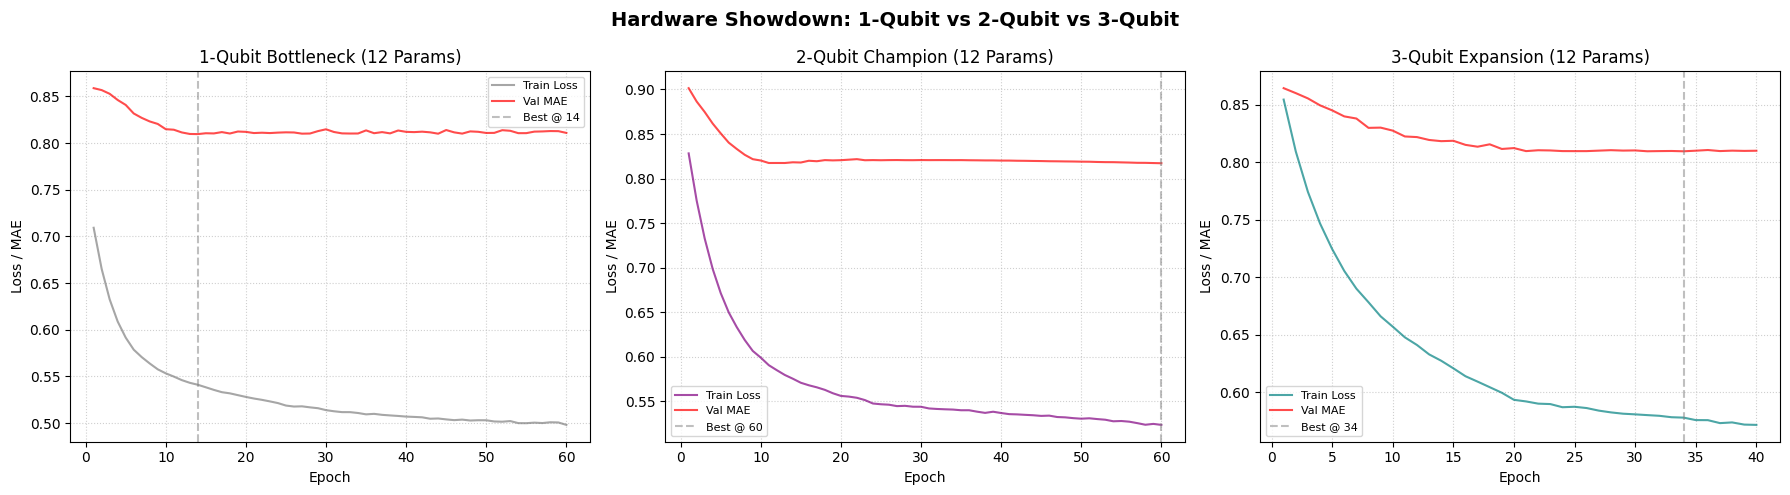

In [ ]:
# ============================================================================
# ### THE ULTIMATE HARDWARE SHOWDOWN: 1Q vs 2Q vs 3Q ###
# ============================================================================

if __name__ == "__main__":
    results = {}

    # ---> THE FIX IS RIGHT HERE <---
    # We explicitly unpack all 4 returned values into 4 separate variables
    mae_d, score_d, train_d, val_d = train_experiment_D_1Qubit()
    results['1-Qubit Bottleneck (12 Params)'] = {'mae': mae_d, 'score': score_d, 'train': train_d, 'val': val_d}

    # 2. Run 2-Qubit Champion (Exp C)
    mae_c, score_c, train_c, val_c = train_experiment_C_Optimized()
    results['2-Qubit Champion (12 Params)'] = {'mae': mae_c, 'score': score_c, 'train': train_c, 'val': val_c}

    # 3. Run 3-Qubit Challenger (Exp F)
    mae_f, score_f, train_f, val_f = train_experiment_F_3Qubit()
    results['3-Qubit Expansion (12 Params)'] = {'mae': mae_f, 'score': score_f, 'train': train_f, 'val': val_f}

    # ===== Summary =====
    print("\n" + "=" * 75)
    print("HARDWARE ABLATION SUMMARY")
    print("=" * 75)
    print(f"{'Experiment':<35} {'Best MAE':>10} {'Qubits':>8}")
    print("-" * 78)
    print(f"{'1-Qubit Bottleneck':<35} {mae_d:>10.4f} {1:>8}")
    print(f"{'2-Qubit Champion':<35} {mae_c:>10.4f} {2:>8}")
    print(f"{'3-Qubit Expansion':<35} {mae_f:>10.4f} {3:>8}")
    print("=" * 78)

    # ===== Plot =====
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['gray', 'purple', 'teal']
    for idx, (name, data) in enumerate(results.items()):
        ax = axes[idx]
        epochs_range = range(1, len(data['train']) + 1)
        ax.plot(epochs_range, data['train'], label='Train Loss', color=colors[idx], alpha=0.7)
        ax.plot(epochs_range, data['val'], label='Val MAE', color='red', alpha=0.7)
        best_epoch = data['val'].index(data['mae']) + 1
        ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best @ {best_epoch}')
        ax.set_title(name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss / MAE')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle('Hardware Showdown: 1-Qubit vs 2-Qubit vs 3-Qubit', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('hardware_showdown.png', dpi=300)
    print("\nSaved showdown plot to 'hardware_showdown.png'")